In [2]:
import tensorflow as tf

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train.shape
X_test.shape
y_train.shape
y_test.shape

(60000, 28, 28)

(10000, 28, 28)

(60000,)

(10000,)

In [4]:
len(X_train)
X_train[0].shape
X_train[0][0]
# There are 60,000 images where each image is of size 28 X 28, It is a grayscale image because there are two channels.

60000

(28, 28)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0.98, 'One sample per image per digit class')

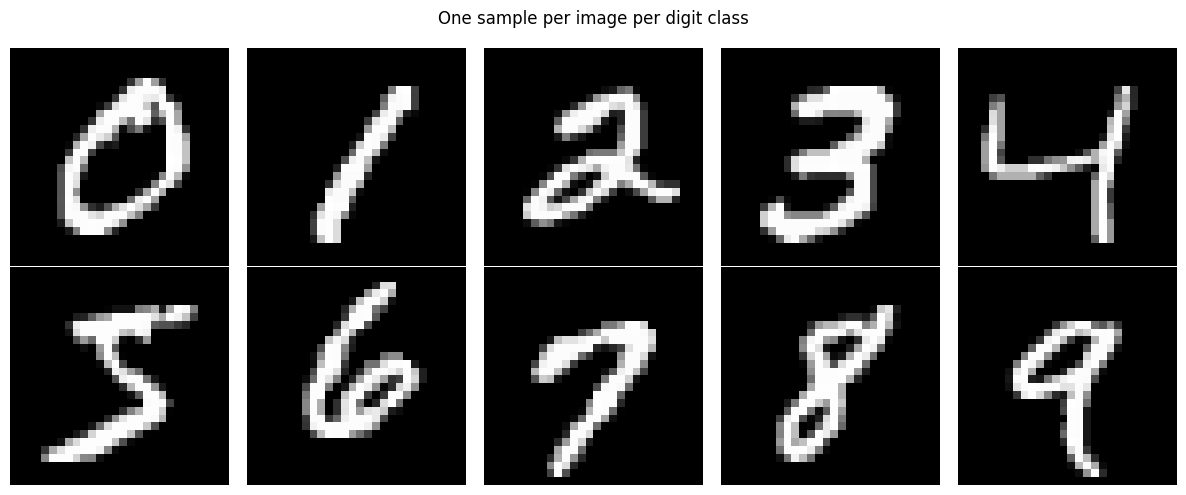

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One sample per image per digit class')

for digit in range(10):
  idx = np.where(y_train == digit)[0][0]
  row, col = divmod(digit, 5)
  _ = axes[row, col].imshow(X_train[idx], cmap='gray')
  _ = axes[row, col].axis('off')

plt.tight_layout()

In [7]:
import collections

train_counts = collections.Counter(y_train.tolist())
test_counts = collections.Counter(y_test.tolist())

print(f'num train test')
for i in range(10):
  print(f'{i}   {train_counts[i]}   {test_counts[i]}')

num train test
0   5923   980
1   6742   1135
2   5958   1032
3   6131   1010
4   5842   982
5   5421   892
6   5918   958
7   6265   1028
8   5851   974
9   5949   1009


In [8]:
28*28
# X_train[0]

784

## Preprocessing step

In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

X_train_flat.shape
X_test_flat.shape

(60000, 784)

(10000, 784)

In [11]:
print("Before flattening :", X_train.shape)
print("After flattening  :", X_train_flat.shape)
print(f"Pixel value range: min: {X_train_flat.min()} max: {X_train_flat.max()}")

Before flattening : (60000, 28, 28)
After flattening  : (60000, 784)
Pixel value range: min: 0.0 max: 1.0


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8528 - loss: 0.4877 - val_accuracy: 0.9668 - val_loss: 0.1252
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9547 - loss: 0.1538 - val_accuracy: 0.9733 - val_loss: 0.0942
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9630 - loss: 0.1207 - val_accuracy: 0.9770 - val_loss: 0.0796
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9717 - loss: 0.0910 - val_accuracy: 0.9785 - val_loss: 0.0767
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9768 - loss: 0.0747 - val_accuracy: 0.9800 - val_loss: 0.0708
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9796 - loss: 0.0652 - val_accuracy: 0.9803 - val_loss: 0.0720
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9820 - loss: 0.0558 - val_accuracy: 0.9808 - val_loss: 0.0705
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9835 - loss: 0.0509 - 

Text(0.5, 0.98, 'MLP training curve')

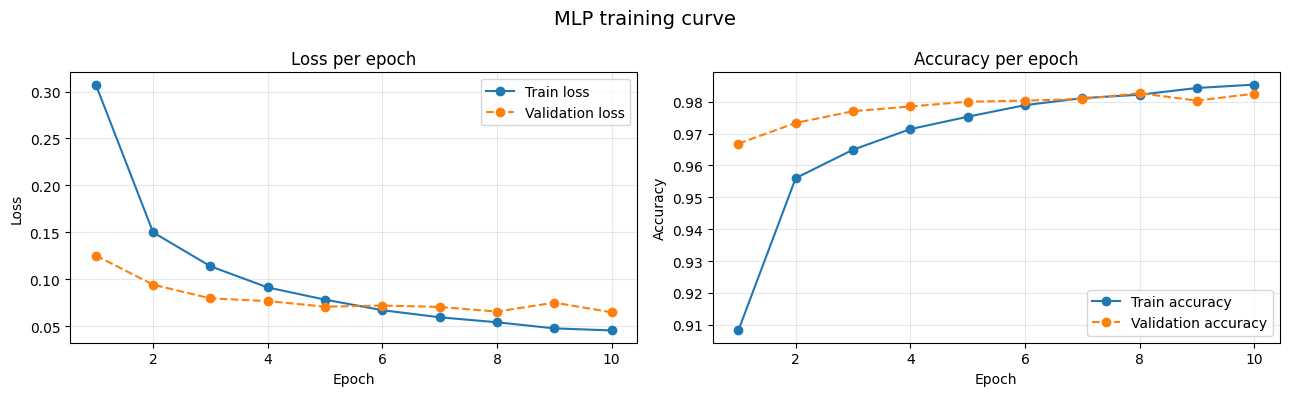

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("MLP training curve", fontsize=14)

epochs_range = range(1, 11)

_ = axes[0].plot(epochs_range, history.history['loss'], label='Train loss', marker='o')
_ = axes[0].plot(epochs_range, history.history['val_loss'],
                 label='Validation loss', marker='o', linestyle='--')
_ = axes[0].set_title("Loss per epoch")
_ = axes[0].set_xlabel("Epoch")
_ = axes[0].set_ylabel("Loss")
_ = axes[0].legend()
_ = axes[0].grid(True, alpha=0.3)

_ = axes[1].plot(epochs_range, history.history['accuracy'], label='Train accuracy', marker='o')
_ = axes[1].plot(epochs_range, history.history['val_accuracy'],
                 label='Validation accuracy', marker='o', linestyle='--')
_ = axes[1].set_title("Accuracy per epoch")
_ = axes[1].set_xlabel("Epoch")
_ = axes[1].set_ylabel("Accuracy")
_ = axes[1].legend()
_ = axes[1].grid(True, alpha=0.3)

plt.tight_layout()

In [16]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)
test_loss
test_accuracy * 100

0.07173644006252289

98.11999797821045

In [17]:
y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
wrong_mask = y_pred != y_test
wrong_indices = np.where(wrong_mask)[0]

print(f'Total test images {len(y_test)}')
print(f'Number of correctly classified images {len(y_test) - len(wrong_indices)}')
print(f'Number of wrongly classified images {len(wrong_indices)}')
print(f'Error indices {len(wrong_indices) / len(y_test) * 100:.2f}%')

Total test images 10000
Number of correctly classified images 9812
Number of wrongly classified images 188
Error indices 1.88%


Text(0.5, 0.98, 'MLP misclassified images — true label vs predicted label')

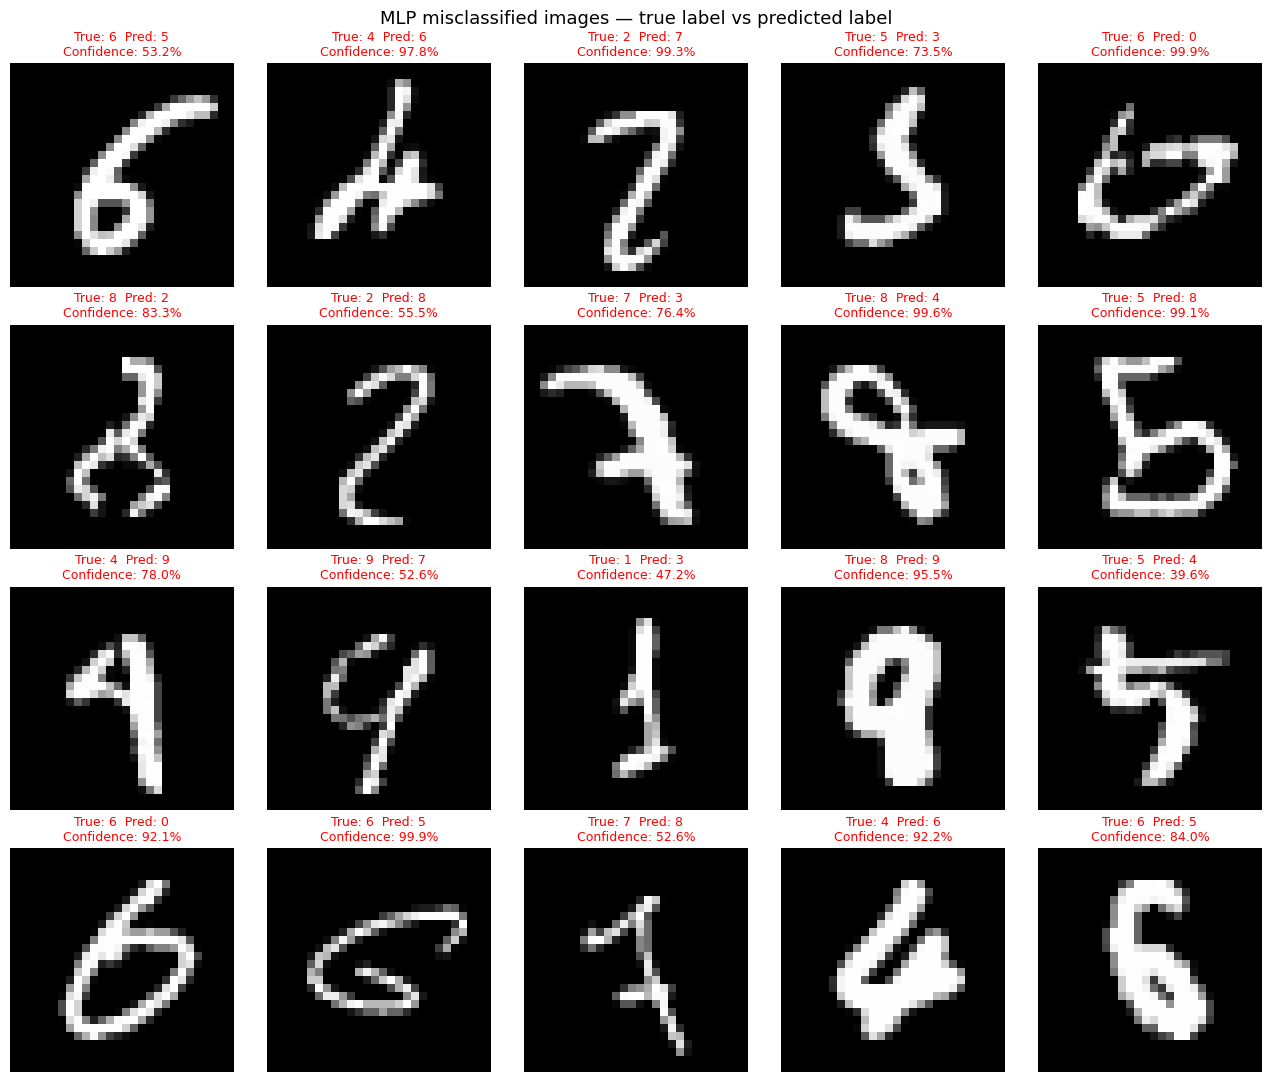

In [18]:
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
fig.suptitle("MLP misclassified images — true label vs predicted label", fontsize=13)

for i, ax in enumerate(axes.flat):
  idx = wrong_indices[i]
  _ = ax.imshow(X_test[idx], cmap='gray')

  true_label = y_test[idx]
  pred_label = y_pred[idx]

  # Get the confidence the model had in its wrong answer
  confidence = y_pred_probs[idx][pred_label] * 100

  _ = ax.set_title(
      f"True: {true_label}  Pred: {pred_label}\n"
      f"Confidence: {confidence:.1f}%",
      fontsize=9,
      color='red'
  )
  _ = ax.axis('off')

plt.tight_layout()

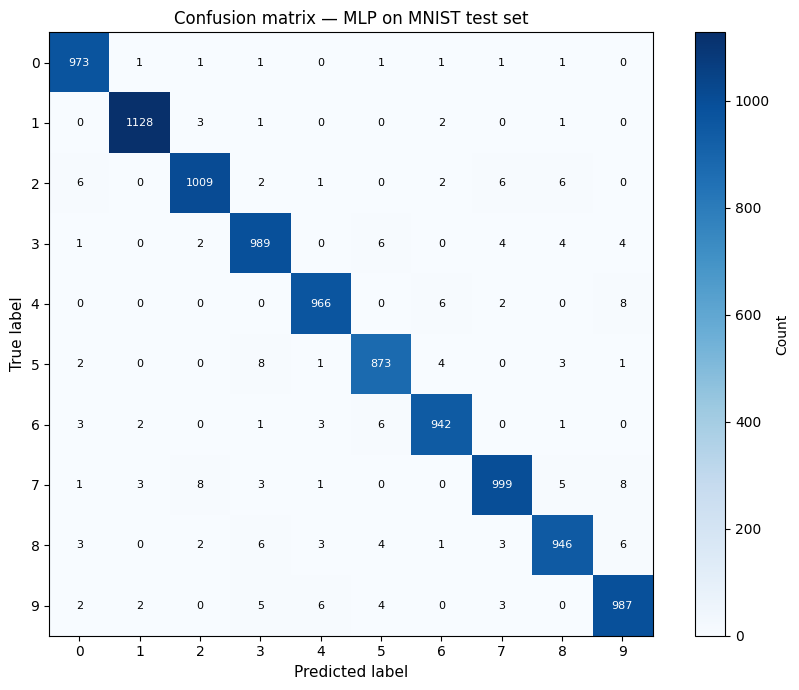

In [19]:
conf_matrix = np.zeros((10, 10), dtype=int)

for true, pred in zip(y_test, y_pred):
  conf_matrix[true][pred] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(conf_matrix, cmap='Blues')

for i in range(10):
  for j in range(10):
    count = conf_matrix[i][j]
    color = 'white' if count > conf_matrix.max() * 0.5 else 'black'
    _ = ax.text(j, i, str(count), ha='center', va='center', fontsize=8, color=color)

_ = ax.set_xticks(range(10))
_ = ax.set_yticks(range(10))
_ = ax.set_xticklabels(range(10))
_ = ax.set_yticklabels(range(10))
_ = ax.set_xlabel("Predicted label", fontsize=11)
_ = ax.set_ylabel("True label", fontsize=11)
_ = ax.set_title("Confusion matrix — MLP on MNIST test set", fontsize=12)
_ = plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()

In [20]:
print("Top confused digit pairs (true → predicted):")
off_diag = conf_matrix.copy()
np.fill_diagonal(off_diag, 0)
for _ in range(5):
  idx = np.unravel_index(off_diag.argmax(), off_diag.shape)
  print(f"  True {idx[0]} predicted as {idx[1]} : {off_diag[idx]} times")
  off_diag[idx] = 0

Top confused digit pairs (true → predicted):
  True 4 predicted as 9 : 8 times
  True 5 predicted as 3 : 8 times
  True 7 predicted as 2 : 8 times
  True 7 predicted as 9 : 8 times
  True 2 predicted as 0 : 6 times


In [21]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_cnn = X_train.reshape(60000, 28, 28, 1)
X_test_cnn = X_test.reshape(10000, 28, 28, 1)


X_train_cnn.shape
X_test_cnn.shape
print("Pixel range:", X_train_cnn.min(), "to", X_train_cnn.max())

(60000, 28, 28, 1)

(10000, 28, 28, 1)

Pixel range: 0.0 to 1.0


In [25]:
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)